# How far ahead does the MILP need to look, and does the answer depend on the price list?

The *same* continuous MILP formulation, driven five different ways over the same 30 kWh
battery, on 40 households — **5 from each of the 8 Fluvius groups** (plain, EV, HP, HP+EV, PV,
PV+EV, PV+HP, PV+HP+EV), full year — and now on **four GEN-I price lists** instead of one.

Two axes, crossed. Every strategy is run on every list, on every household.

### The strategy axis

Each strategy is a combination of three choices:

| | |
|---|---|
| **horizon** | how far each solve sees: day (96 intervals), week (672), month, or the whole year |
| **execution** | `block` — carry out the entire plan, then re-plan · `receding` — carry out the first interval only, then re-plan (MPC) |
| **SOC mode** | `fixed50` — every solve starts *and* ends at 50 % of capacity · `carry` — only the first period starts at 50 %, then each period ends wherever it likes and the next starts from exactly that state of charge |

The `carry` family is what removes the artificial "hand the battery back at 15 kWh every
midnight" constraint. It is commented out in `Horizon_Comparison.STRATEGIES` alongside
`week_receding` and `week_receding_carry`; at 35 136 solves of 672 intervals each the receding
week costs ~3 h per household, for a result the earlier 30-household run already showed (95.0 %
of the achievable saving, only 0.8 points better than the 19-second `week_block`). Uncomment
them in the module and both families come back into every table and panel below.

### The price-list axis

Four GEN-I household products, all four billed and optimized under `si_samooskrba`:

| List | `paket_id` | Import price [EUR/kWh] | Export credit [EUR/kWh] | How fast the price moves |
|---|---|---|---|---|
| **Dinamični** | `GENI_SAMO_DINAMICNI` | SIPX + 0.01199, uncapped | SIPX − 0.01199, per interval | every 15 minutes |
| **Aktivni** | `GENI_SAMO_AKTIVNI` | 4 blocks, 0.04090 → 0.19290 | 4 blocks, 0.00190 → 0.14990 | 4 fixed windows, same every day |
| **Redni 1T** | `GENI_SAMO_REDNI` | 0.10290 flat (ET) | 0.05390 flat | never |
| **Redni 2T** | `GENI_REDNI` | VT 0.11990 / MT 0.09790 | **nothing** — `tip_odkupa=NI` | VT 06:00–22:00 working days, MT otherwise |

**Why the price list belongs on the same chart as the horizon.** How far ahead a controller has
to look is a property of the *price signal*, not of the solver. A list that re-prices every
quarter hour on a market nobody can see a week out is the hard case; a list that is one flat
number all year has almost nothing left for a long horizon to discover, because the only things
a longer view can still exploit are the seasonal shape of the household's own PV and load and
the annual excess-power ratchet. If the horizon penalty collapses when the price list flattens,
that is the mechanism showing itself.

**Every list runs under `si_samooskrba`, including the plain two-tariff one.** Intra-interval
netting is *physical* — within one 15-minute interval the meter registers the residual whatever
the contract says. What the *contract* decides is only what a surplus is worth, and that is read
off the package: `tip_odkupa=NI` on `GENI_REDNI` makes `si_obracun._cena_oddaje` return 0.00000.
Routing it through `si_dobava` instead would credit an exported kWh at the full retail rate
*including* network charges, levies and VAT, which makes grid arbitrage unbounded and the
comparison meaningless.

**NET metering is deliberately absent.** It is closed to new contracts and settles once a year,
so it is neither a list a household can choose into nor a baseline. See
`Multuser_Battery_Size_Optimization` for it as a legacy reference line.

**Read `Gap_pct` within a list, not across.** It is the share of *that list's* achievable saving
a strategy throws away, so the whole-year solve is 0 % on all four by construction. One point of
gap is worth a very different number of euros on each — section 4 puts the achievable saving
next to the gaps so the two are never confused.

### Three things that make the comparison fair

**The MILP only produces a dispatch.** Every executed trajectory is priced afterwards by one
shared evaluator (`price_interval`) walking interval by interval with a single running peak
state, using that run's own price list. The excess-power (konica) charge is a running maximum
over the whole year, so no strategy may price its own peaks. Checked against
`run_milp_benchmark`'s internal pricing on a one-week solve: identical to 0.00e+00 EUR.

**The controller knows its true peak state.** `_PeakSeedView` replaces the environment's
no-battery peak seed with the peak the executed trajectory has actually set.

**The year is always closed at 50 %.** Under *both* SOC modes the run starts at 15 kWh and the
final period must end at 15 kWh — otherwise a free-terminal strategy would simply sell off its
opening charge and book it as a saving. Only the *interior* boundaries differ between the
families. A useful consequence: `full_period_carry` has just one period, so it must come out
exactly equal to `full_period`, and that identity is visible in the table below.

In [27]:
### Imports
import time
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Patch, Rectangle

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)

print(f"Horizon_Comparison loaded: {len(hc.TARIFFS)} price lists, "
      f"{len(hc.STRATEGIES)} strategies.")

Horizon_Comparison loaded: 4 price lists, 5 strategies.


## 1. Configuration

The study parameters live in `Horizon_Comparison.py` so the notebook and the batch script cannot
drift apart — including `TARIFFS`, which is now a full axis rather than a single `PAKET_ID`.

`RUN_BATCH = True` recomputes everything — ~1.2 h per household-unit *per price list*, so ~5 h
for all 40 units on one list and ~20 h for all four on 10 workers. By default the notebook reads
the CSVs the batch already wrote. Work is checkpointed per (household, list), so adding a price
list only solves the new one; the CSVs written before this study grew a tariff axis are read
back as the default list's rows without being redone.

In [ ]:
UNITS = hc.study_units()          # (dataset group, household id) pairs
TARIFFS = list(hc.TARIFF_ORDER)   # price lists, every one run on every unit
JOBS = hc.study_jobs(UNITS, TARIFFS)
RESULTS_DIR = hc.RESULTS_DIR
RUN_BATCH = False                 # True -> recompute (~20 h on 10 workers, resumable)
N_WORKERS = 10

print(f"groups             : {', '.join(hc.DATASET_GROUPS)}")
print(f"households         : {hc.HOUSEHOLDS_PER_GROUP} per group = {len(UNITS)} units")
print(f"battery            : {hc.BATTERY_CAPACITY_KWH:.0f} kWh, "
      f"{min(hc.C_RATE * hc.BATTERY_CAPACITY_KWH, hc.INVERTER_MAX_KW):.1f} kW, "
      f"eff {hc.CHARGE_EFFICIENCY:.2f}/{hc.DISCHARGE_EFFICIENCY:.2f}")
print(f"SOC                : start {hc.SOC_FRACTION:.0%}, "
      f"final period ends at {hc.SOC_FRACTION:.0%}; interior boundaries per SOC mode")
print(f"peak reset         : {hc.PEAK_RESET_MONTHS} (None = one annual ratchet)")
print(f"pricing regime     : {hc.PRICING_REFERENCE_YEAR}, scheme {hc.PRICING_SCHEME} for every list")

print(f"\nprice lists        : {len(TARIFFS)}")
for name in TARIFFS:
    spec = hc.TARIFFS[name]
    print(f"   {name:11s} {spec['paket_id']:20s} {spec['structure']:20s} "
          f"{'exports credited' if spec['buyback'] else 'no buyback'}")

print(f"\nstrategies         : {len(hc.STRATEGIES)}")
for name, (horizon, execution, soc_mode) in hc.STRATEGIES.items():
    print(f"   {name:20s} horizon={horizon:7s} execution={execution:9s} soc={soc_mode}")

print(f"\njobs               : {len(UNITS)} units x {len(TARIFFS)} lists x "
      f"{len(hc.STRATEGIES)} strategies = {len(JOBS) * len(hc.STRATEGIES):,} runs")

groups             : Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV, Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV
households         : 5 per group = 40 units
battery            : 30 kWh, 11.0 kW, eff 0.95/0.95
SOC                : start 50%, final period ends at 50%; interior boundaries per SOC mode
peak reset         : None (None = one annual ratchet)
pricing regime     : 2026, scheme si_samooskrba for every list

price lists        : 4
   Dinamični   GENI_SAMO_DINAMICNI  dynamic (SIPX)       exports credited
   Aktivni     GENI_SAMO_AKTIVNI    4 time blocks        exports credited
   Redni 1T    GENI_SAMO_REDNI      flat (ET)            exports credited
   Redni 2T    GENI_REDNI           two-tariff (VT/MT)   no buyback

strategies         : 5
   day_block            horizon=day     execution=block     soc=fixed50
   day_receding         horizon=day     execution=receding  soc=fixed50
   week_block           horizon=week    execution=block     soc=fixed50
   month_block

## 2. Load results

One CSV per (household, price list). A run is identified by `hc.KEY_COLUMNS =
["Dataset", "Household", "Tariff"]`, because the whole-year optimum a strategy is scored against
is the optimum *for that household on that list*.

Only units that finished **every** strategy on **every** ready list enter the comparison, so
every number below is averaged over exactly the same households on all four lists.

In [ ]:
if RUN_BATCH:
    hc.run_batch(UNITS, tariffs=TARIFFS, output_dir=RESULTS_DIR, n_workers=N_WORKERS)

df_all = hc.collect_results(RESULTS_DIR)
if df_all.empty:
    raise SystemExit(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python Horizon_Comparison.py --per-group 5 --workers 10  (~20 h), "
        f"or set RUN_BATCH = True above."
    )

# The batch writes each (unit, list) CSV after every finished strategy, so this
# notebook is readable at any point during the run.
expected = list(hc.STRATEGIES)
done = {k: set(g) for k, g in df_all.groupby(hc.KEY_COLUMNS)["Strategy"]}
complete_keys = {k for k, s in done.items() if set(expected) <= s}

units_done = {t: {(d, h) for d, h, t2 in complete_keys if t2 == t} for t in TARIFFS}
TARIFFS_READY = [t for t in TARIFFS if units_done[t]]
if not TARIFFS_READY:
    raise SystemExit(
        "No household-unit has every strategy on any price list yet, so there is nothing to "
        "compare against a whole-year optimum. Re-run once the batch has finished a unit "
        "(~1.2 h each)."
    )

print(f"{'price list':12s}{'complete units':>16s}{'runs on disk':>14s}")
for t in TARIFFS:
    rows = int((df_all['Tariff'] == t).sum())
    print(f"{t:12s}{len(units_done[t]):>10d} / {len(UNITS):<3d}"
          f"{rows:>9,d} / {len(UNITS) * len(expected):<,d}")
if len(TARIFFS_READY) < len(TARIFFS):
    print(f"\nNot started yet, and left out of everything below: "
          f"{', '.join(t for t in TARIFFS if t not in TARIFFS_READY)}")

# One balanced panel: the units that are finished on EVERY ready list. Without
# this the lists would be averaged over different households and a difference
# between price lists could just be a difference in who is in the sample.
balanced = set.intersection(*(units_done[t] for t in TARIFFS_READY))
if not balanced:
    raise SystemExit(
        "No household-unit is finished on every ready price list, so the lists cannot be "
        "compared on a common sample. Let the batch finish one unit across all lists."
    )
dropped = {t: len(units_done[t]) - len(balanced) for t in TARIFFS_READY}
if any(dropped.values()):
    print("\nHeld out to keep the panel balanced (finished on some lists but not all): "
          + ", ".join(f"{t} {n}" for t, n in dropped.items() if n))

keys = pd.MultiIndex.from_tuples(
    [(d, h, t) for t in TARIFFS_READY for d, h in sorted(balanced)], names=hc.KEY_COLUMNS
)
df_all = df_all.set_index(hc.KEY_COLUMNS).loc[keys].reset_index()

print(f"\nComparing {len(balanced)} units x {len(TARIFFS_READY)} price lists x {len(expected)} "
      f"strategies = {len(df_all)} runs, {df_all['N_Solves'].sum():,.0f} MILP solves, "
      f"{df_all['Runtime_s'].sum() / 3600:.1f} solver-hours.")
print(f"Max SOC drift over every run: {df_all['SOC_Drift_kWh'].max():.2e} kWh "
      f"(0 means no solve ever ended infeasible)")

done -> Fluvius_user_001.csv (5 strategies)
done -> Fluvius_user_002.csv (5 strategies)
done -> Fluvius_user_003.csv (5 strategies)
done -> Fluvius_user_004.csv (5 strategies)


## 3. The comparison table

The headline number is **`Gap_pct`** — the share of the *achievable* saving a strategy throws
away by not seeing the whole year:

    Gap_pct = 100 % − (no-battery cost − strategy cost) / (no-battery cost − whole-year optimum)

Both reference points are resolved **per household and per price list**, so `full_period` is 0 %
on every list by construction and bigger is worse. Reporting it this way makes the 40 households
comparable to each other: their absolute bills differ by an order of magnitude (a 2 MWh/a
household against a 16 MWh/a heat-pump-plus-EV one), but the fraction of the attainable benefit
each strategy secures does not depend on that scale.

**The same trick does not make the four price lists comparable in euros.** A denominator of its
own is exactly what makes `Gap_pct` scale-free, and the denominators differ by a large factor
between lists — so read the percentages *down* a list, and read the `Achievable [EUR/a]` column
next to them before comparing *across* lists. Section 4 plots both.

`Grid charged [%]` is the share of everything the battery took in that came from the grid rather
than from the household's own surplus. On a list with wide fixed price blocks it can approach
100 %: that is the battery running pure buy-low/sell-high arbitrage against the price list, not
storing PV, and it is worth knowing before calling a large achievable saving a battery benefit.

In [ ]:
summary, df_scored = hc.summarize(df_all)

# The achievable saving is the whole-year solve's own saving -- the denominator
# every Gap_pct on that list is a percentage of.
achievable = summary.xs(hc.REFERENCE_STRATEGY, level="Strategy")["Savings_EUR"]

summary_display = summary.assign(
    Achievable_EUR=[achievable[t] for t, _ in summary.index],
    Grid_Charged_pct=100.0 * summary["Grid_Charged_kWh"] / summary["Charged_kWh"].where(lambda s: s > 0),
).drop(columns=["Charged_kWh", "Grid_Charged_kWh"])[[
    "Units", "SOC_Mode", "Gap_pct", "Worst_Gap_pct", "Best_Gap_pct", "Gap_EUR",
    "Achievable_EUR", "Cost_EUR", "Savings_EUR", "Cycles", "Grid_Charged_pct",
    "Peak_kW", "Solves", "Runtime_s",
]].rename(columns={
    "SOC_Mode": "SOC mode",
    "Gap_pct": "Gap [%]",
    "Worst_Gap_pct": "Worst unit [%]",
    "Best_Gap_pct": "Best unit [%]",
    "Gap_EUR": "Gap [EUR/a]",
    "Achievable_EUR": "Achievable [EUR/a]",
    "Cost_EUR": "Cost [EUR/a]",
    "Savings_EUR": "Saving [EUR/a]",
    "Cycles": "Full cycles/a",
    "Grid_Charged_pct": "Grid charged [%]",
    "Peak_kW": "Peak import [kW]",
    "Solves": "MILP solves",
    "Runtime_s": "Solver time [s]",
})
summary_display.round(2)

Units SOC mode  Gap [%]  Worst unit [%]  \
Tariff    Strategy                                                
Dinamični day_block        40  fixed50    16.39           24.58   
          day_receding     40  fixed50     6.58           14.42   
          week_block       40  fixed50     5.06            9.85   
          month_block      40  fixed50     2.00            3.32   
          full_period      40  fixed50    -0.00            0.00   

                        Best unit [%]  Gap [EUR/a]  Achievable [EUR/a]  \
Tariff    Strategy                                                       
Dinamični day_block             11.04       119.23              740.99   
          day_receding           0.79        46.78              740.99   
          week_block             1.30        36.21              740.99   
          month_block            0.68        14.46              740.99   
          full_period           -0.00         0.00              740.99   

                        Cost [EUR/a]  Saving [EUR/a]  Full cycles/a  \
Tariff    Strategy                                                    
Dinamični day_block           396.77          621.76         256.64   
          day_receding        324.32          694.21         242.97   
          week_block          313.76          704.78         251.00   
          month_block         292.01          726.53         254.90   
          full_period         277.54          740.99         262.81   

                        Grid charged [%]  Peak import [kW]  MILP solves  \
Tariff    Strategy                                                        
Dinamični day_block                89.62             15.30        366.0   
          day_receding             88.81             15.16      35135.0   
          week_block               89.33             15.10         53.0   
          month_block              89.66             14.99         12.0   
          full_period              90.18             15.29          1.0   

                        Solver time [s]  
Tariff    Strategy                       
Dinamični day_block               23.08  
          day_receding          1977.96  
          week_block              20.09  
          month_block             36.23  
          full_period             93.25

In [ ]:
### Mean gap [%] per dataset group, one block of columns per price list
by_group = hc.summarize_by_group(df_scored)
by_group.round(2)

Tariff           Dinamični                                                
Strategy         day_block day_receding week_block month_block full_period
Dataset                                                                   
Fluvius              22.20        12.36       8.73        3.04         0.0
Fluvius_EV           18.00         7.62       5.95        2.27        -0.0
Fluvius_HP           16.76         8.29       5.76        2.13        -0.0
Fluvius_HP_EV        13.43         2.99       2.95        1.35         0.0
Fluvius_PV           17.95         8.15       5.80        2.22        -0.0
Fluvius_PV_EV        14.86         4.41       3.71        1.64         0.0
Fluvius_PV_HP        15.03         5.19       4.42        1.98         0.0
Fluvius_PV_HP_EV     12.88         3.61       3.20        1.41         0.0

In [ ]:
### Every household-unit on every price list, gap to that unit's whole-year optimum [%]
per_unit = (
    df_scored.pivot_table(index=hc.KEY_COLUMNS, columns="Strategy", values="Gap_pct")
    .reindex(columns=[s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])])
    .reindex(TARIFFS_READY, level="Tariff")
)
per_unit.round(2)

Strategy                              day_block  day_receding  week_block  \
Dataset          Household Tariff                                           
Fluvius          1         Dinamični      22.36         12.79        8.79   
                 2         Dinamični      22.08         12.10        8.74   
                 3         Dinamični      20.04          9.98        7.55   
                 4         Dinamični      21.95         12.53        8.73   
                 5         Dinamični      24.58         14.42        9.85   
Fluvius_EV       1         Dinamični      20.10         10.12        7.68   
                 2         Dinamični      16.20          4.58        3.30   
                 3         Dinamični      20.35         10.97        8.05   
                 4         Dinamični      17.22          7.29        5.95   
                 5         Dinamični      16.13          5.12        4.75   
Fluvius_HP       1         Dinamični      13.85          5.86        4.81   
                 2         Dinamični      16.38          7.64        5.80   
                 3         Dinamični      19.75          9.28        6.20   
                 4         Dinamični      19.06         12.78        7.53   
                 5         Dinamični      14.74          5.87        4.44   
Fluvius_HP_EV    1         Dinamični      13.26          1.13        1.30   
                 2         Dinamični      11.95          2.45        2.11   
                 3         Dinamični      11.04          1.10        1.63   
                 4         Dinamični      15.04          4.09        4.02   
                 5         Dinamični      15.86          6.16        5.68   
Fluvius_PV       1         Dinamični      14.66          5.30        3.97   
                 2         Dinamični      17.93          8.15        5.74   
                 3         Dinamični      19.10         10.01        6.73   
                 4         Dinamični      21.66         11.31        8.03   
                 5         Dinamični      16.40          5.98        4.51   
Fluvius_PV_EV    1         Dinamični      11.40          1.21        1.49   
                 2         Dinamični      19.95          8.92        6.94   
                 3         Dinamični      12.08          1.26        1.61   
                 4         Dinamični      16.68          6.80        5.21   
                 5         Dinamični      14.19          3.84        3.31   
Fluvius_PV_HP    1         Dinamični      13.09          3.46        3.26   
                 2         Dinamični      14.74          5.54        4.57   
                 3         Dinamični      15.49          6.88        5.38   
                 4         Dinamični      17.39          5.63        5.36   
                 5         Dinamični      14.45          4.46        3.54   
Fluvius_PV_HP_EV 1         Dinamični      14.08          4.31        3.99   
                 2         Dinamični      11.91          3.10        2.62   
                 3         Dinamični      11.29          0.79        1.35   
                 4         Dinamični      15.01          6.66        5.55   
                 5         Dinamični      12.10          3.17        2.47   

Strategy                              month_block  full_period  
Dataset          Household Tariff                               
Fluvius          1         Dinamični         3.07          0.0  
                 2         Dinamični         3.06          0.0  
                 3         Dinamični         2.68          0.0  
                 4         Dinamični         3.07          0.0  
                 5         Dinamični         3.32          0.0  
Fluvius_EV       1         Dinamični         2.76         -0.0  
                 2         Dinamični         1.45          0.0  
                 3         Dinamični         2.88          0.0  
                 4         Dinamični         2.28         -0.0  
                 5         Dinamični         1.96 

## 4. Plots

The gap panels all read in percent of the achievable saving, so households of very different
size can sit on the same axis — but that denominator is per price list, so the first thing
plotted is what each list's achievable saving actually is.

**The colour scheme is the price list.** One hue per list, held fixed across every panel:
Dinamični blue, Aktivni orange, Redni 1T aqua, Redni 2T magenta. The four were checked for
lightness band, chroma floor, all-pairs colour-vision separation (protan/deutan ΔE ≥ 8, OKLab
×100) and contrast against the chart surface before being used. Within a list, the SOC mode is
the *shade plus a hatch* of that same hue, never a new colour — so identity is never carried by
colour alone, and the two axes of the study never fight over the same channel.

In [ ]:
### Shared chart styling
# Categorical hues, one per price list, assigned in a fixed order and never
# cycled or reassigned when a list drops out of the sample. Validated on the
# all-pairs list against the #fcfcfb surface: OKLCH L in [0.43, 0.77], chroma
# >= 0.10, worst normal-vision OKLab dE 20.2 (floor 15), worst protan/deutan dE
# 9.2 (target 8), contrast >= 2.74 (aqua sits under 3:1, which is why every
# panel using it carries direct value labels and a table view above).
TARIFF_COLOR = {
    "Dinamični": "#2a78d6",   # blue
    "Aktivni":   "#eb6834",   # orange
    "Redni 1T":  "#1baf7a",   # aqua
    "Redni 2T":  "#a03fa0",   # magenta
}
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})


def _mix(hex_color, other, t):
    """Blend two hex colours, t = share of `other`."""
    a = np.array(to_rgb(hex_color))
    b = np.array(to_rgb(other))
    return tuple((1.0 - t) * a + t * b)


# Sequential ramp per list: ONE hue, light -> dark, for the magnitude heatmaps.
# Built from that list's categorical hue so a panel is never a different colour
# system from the bar it belongs to.
TARIFF_RAMP = {
    t: LinearSegmentedColormap.from_list(
        f"ramp_{t}", [_mix(c, "#ffffff", 0.88), _mix(c, "#ffffff", 0.45), c, _mix(c, "#0b0b0b", 0.45)]
    )
    for t, c in TARIFF_COLOR.items()
}
# The SOC mode is a shade of the SAME hue plus a hatch or a marker shape, so it
# never competes with the price list for the colour channel.
MODE_SHADE = {"fixed50": 0.0, "carry": 0.55}      # share of white mixed in
MODE_HATCH = {"fixed50": None, "carry": "///"}
MODE_MARKER = {"fixed50": "o", "carry": "^"}
MODE_LABEL = {"fixed50": "SOC pinned to 50 % every period",
              "carry": "SOC carried across periods"}


def strat_color(tariff, strat):
    """Fill for one (price list, strategy): the list's hue, shaded by SOC mode."""
    return _mix(TARIFF_COLOR[tariff], "#ffffff", MODE_SHADE[hc.STRATEGIES[strat][2]])


def fmt_pct(v, places=1):
    """Percent label with the MIP-gap sign noise squeezed out.

    `full_period` is solved to a 0.1 % relative gap, so a gap that is zero by
    construction lands a few thousandths either side of it and would otherwise
    print as "-0.0".
    """
    return f"{0.0 if abs(v) < 0.05 else v:.{places}f}"


def panel_title(ax, tariff, fontsize=12):
    """Panel heading: ink text under a bar in the list's hue.

    The text itself stays in the ink token -- the colour band beside it is what
    carries the identity, so the panel is still readable in greyscale.
    """
    ax.set_title(tariff, color=INK, fontsize=fontsize)
    ax.add_patch(Rectangle((0, 1.004), 1, 0.02, transform=ax.transAxes, clip_on=False,
                           facecolor=TARIFF_COLOR[tariff], edgecolor="none", zorder=5))


STRAT_ORDER = [s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])]
SOC_MODES = list(dict.fromkeys(hc.STRATEGIES[s][2] for s in STRAT_ORDER))
LABEL = {
    "day_block": "day, block",
    "day_receding": "day, receding",
    "week_block": "week, block",
    "week_receding": "week, receding",
    "month_block": "month, block",
    "full_period": "whole year",
    "day_block_carry": "day, block",
    "day_receding_carry": "day, receding",
    "week_block_carry": "week, block",
    "week_receding_carry": "week, receding",
    "month_block_carry": "month, block",
    "full_period_carry": "whole year",
}
_per_group = df_scored.groupby("Dataset")["Household"].nunique()
SAMPLE = f"Mean over {len(balanced)} households" + (
    f", {int(_per_group.iloc[0])} from each of the {len(_per_group)} Fluvius groups"
    if _per_group.nunique() == 1 else f" across {len(_per_group)} Fluvius groups"
)


def tariff_legend(ax, tariffs=None, **kw):
    """Legend keyed on the price list -- present on every panel with >= 2 lists."""
    tariffs = tariffs or TARIFFS_READY
    handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=TARIFF_COLOR[t]) for t in tariffs]
    return ax.legend(handles, tariffs, **kw)


def soc_mode_legend(ax, kind="patch", **kw):
    """Second legend for the SOC mode, only drawn when both families are present."""
    if len(SOC_MODES) < 2:
        return None
    if kind == "patch":
        handles = [Patch(facecolor=_mix(MUTED, "#ffffff", MODE_SHADE[m]),
                         hatch=MODE_HATCH[m], edgecolor=INK_2) for m in SOC_MODES]
    else:
        handles = [plt.Line2D([], [], marker=MODE_MARKER[m], ls="", ms=8, color=MUTED)
                   for m in SOC_MODES]
    return ax.legend(handles, [MODE_LABEL[m] for m in SOC_MODES], **kw)


print(f"Style ready: {len(TARIFFS_READY)} price lists x {len(STRAT_ORDER)} strategies, "
      f"SOC modes {', '.join(SOC_MODES)}.")

Style ready: 1 price lists x 5 strategies, SOC modes fixed50.


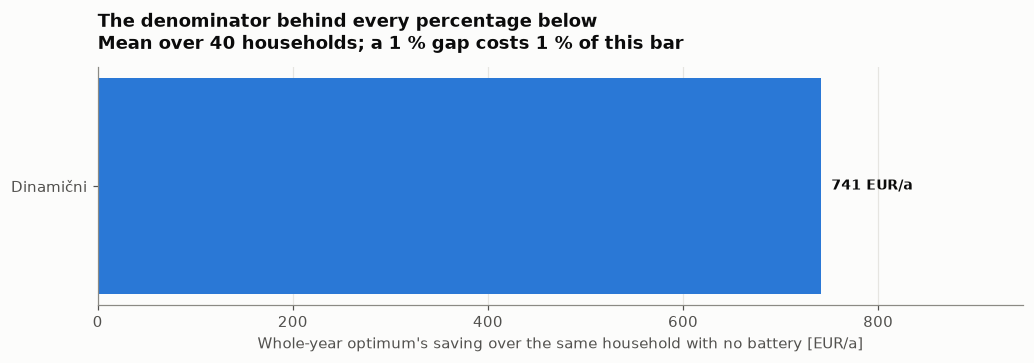

In [ ]:
### What one point of gap is worth: the achievable saving on each list
fig, ax = plt.subplots(figsize=(9.5, 3.4))

vals = [achievable[t] for t in TARIFFS_READY]
ypos = np.arange(len(TARIFFS_READY))[::-1]

ax.barh(ypos, vals, height=0.62, color=[TARIFF_COLOR[t] for t in TARIFFS_READY])
for y, v in zip(ypos, vals):
    ax.annotate(f"{v:,.0f} EUR/a", xy=(v, y), xytext=(7, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9, fontweight="semibold")

ax.set_yticks(ypos, TARIFFS_READY)
ax.set_xlim(0, max(vals) * 1.28)
ax.set_xlabel("Whole-year optimum's saving over the same household with no battery [EUR/a]")
ax.set_title("The denominator behind every percentage below\n"
             f"Mean over {len(balanced)} households; a 1 % gap costs 1 % of this bar")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

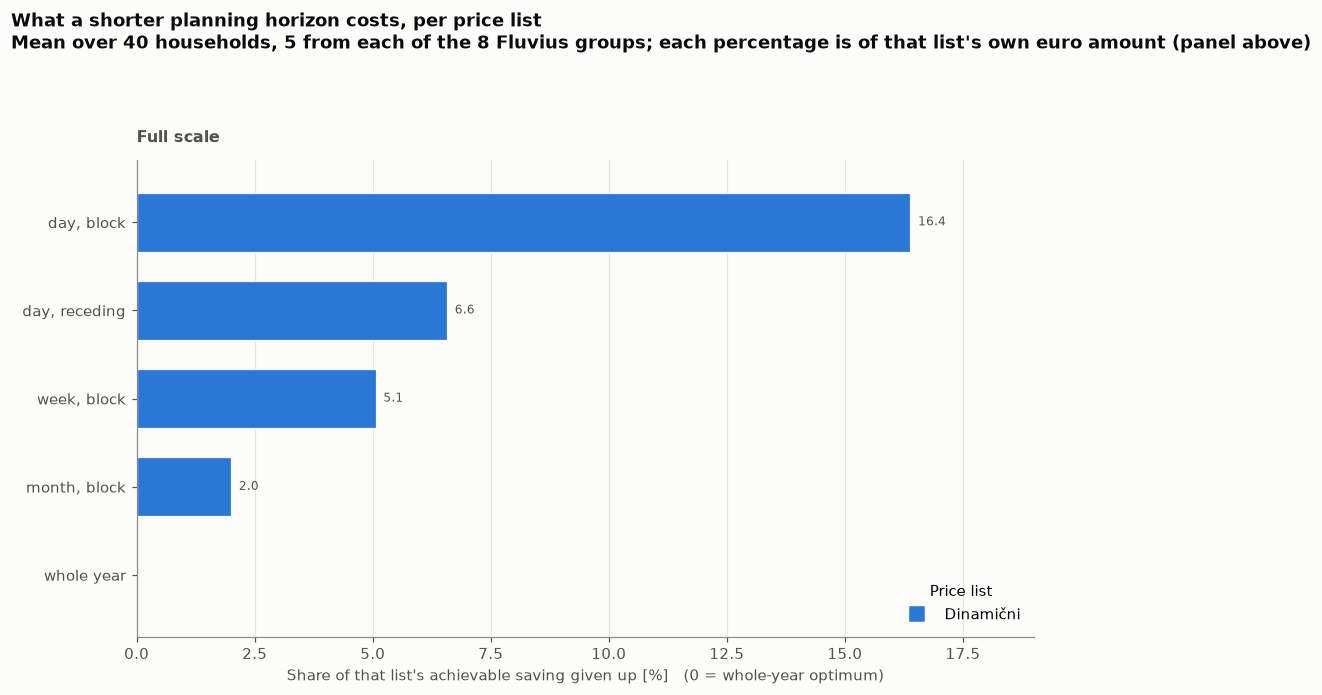

In [ ]:
### What a shorter planning horizon costs, in % of the achievable saving
n_t = len(TARIFFS_READY)
group_h = 0.78
bar_h = group_h / n_t
base = np.arange(len(STRAT_ORDER))[::-1]


def gap_of(tariff, strat):
    return float(summary.loc[(tariff, strat), "Gap_pct"])


def draw_groups(ax, xmax):
    """One group of bars per strategy, one bar per price list, first list on top."""
    for i, tariff in enumerate(TARIFFS_READY):
        ypos = base + group_h / 2 - bar_h * (i + 0.5)
        gaps = [gap_of(tariff, s) for s in STRAT_ORDER]
        bars = ax.barh(ypos, gaps, height=bar_h * 0.86,   # surface gap between adjacent bars
                       color=[strat_color(tariff, s) for s in STRAT_ORDER],
                       edgecolor=SURFACE, linewidth=0.8)
        for patch, s in zip(bars, STRAT_ORDER):
            hatch = MODE_HATCH[hc.STRATEGIES[s][2]]
            if hatch:                   # carry, so the SOC mode is never colour-only
                patch.set_hatch(hatch)
                patch.set_edgecolor(_mix(TARIFF_COLOR[tariff], "#0b0b0b", 0.3))
        for y, v in zip(ypos, gaps):
            # Label only bars that both round to something and fit on this axis;
            # a label pinned at a clipped bar end would read as its value.
            if v > 0.05 and v < xmax * 0.97:
                ax.annotate(fmt_pct(v), xy=(v, y), xytext=(5, 0), textcoords="offset points",
                            va="center", color=INK_2, fontsize=8)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--")
    ax.set_xlim(0, xmax)
    ax.set_ylim(-0.7, len(STRAT_ORDER) - 0.3)
    ax.grid(axis="y", visible=False)


# One list usually dwarfs the rest, which IS the headline -- so the full scale
# is the main panel, and the others get a zoom beside it rather than a rescale
# that would hide the difference.
widest = max(TARIFFS_READY, key=lambda t: max(gap_of(t, s) for s in STRAT_ORDER))
rest = [t for t in TARIFFS_READY if t != widest]
zoom_max = max((gap_of(t, s) for t in rest for s in STRAT_ORDER), default=0.0) * 1.35

if rest and zoom_max > 0:
    fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(12.8, 6.4), sharey=True,
                                      gridspec_kw={"width_ratios": [2.0, 1.0]})
else:
    fig, ax = plt.subplots(figsize=(9.5, 6.4))
    ax_zoom = None

draw_groups(ax, max(float(summary["Gap_pct"].max()) * 1.16, 1.0))
ax.set_yticks(base, [LABEL[s] for s in STRAT_ORDER])
ax.set_xlabel("Share of that list's achievable saving given up [%]   (0 = whole-year optimum)")
ax.set_title("Full scale", fontsize=10.5, color=INK_2)
leg = tariff_legend(ax, loc="lower right", title="Price list")
if soc_mode_legend(ax, kind="patch", loc="center right", title="SOC mode"):
    ax.add_artist(leg)

if ax_zoom is not None:
    draw_groups(ax_zoom, max(zoom_max, 0.5))
    ax_zoom.set_xlabel("Same bars [%]")
    ax_zoom.set_title(f"Zoomed to {', '.join(rest)}\n({widest} runs off the right edge)",
                      fontsize=10.5, color=INK_2)

fig.suptitle("What a shorter planning horizon costs, per price list\n"
             f"{SAMPLE}; each percentage is of that list's own euro amount (panel above)",
             x=0.005, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

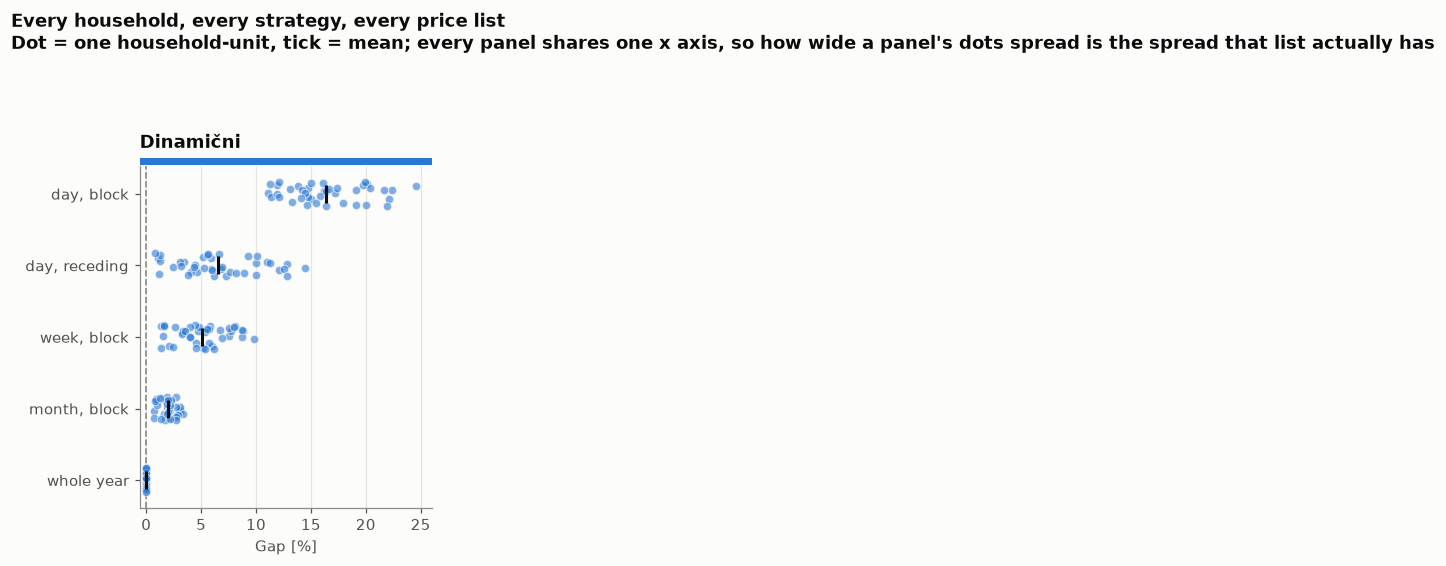

In [ ]:
### Spread across households: one dot per household-unit, one panel per price list
fig, axes = plt.subplots(1, len(TARIFFS_READY), figsize=(4.0 * len(TARIFFS_READY), 5.2),
                         sharex=True, sharey=True, squeeze=False)
rng = np.random.default_rng(0)
xmax = float(df_scored["Gap_pct"].max())

for ax, tariff in zip(axes[0], TARIFFS_READY):
    sub = df_scored[df_scored["Tariff"] == tariff]
    for i, strat in enumerate(STRAT_ORDER):
        y = len(STRAT_ORDER) - 1 - i
        vals = sub.loc[sub["Strategy"] == strat, "Gap_pct"]
        soc_mode = hc.STRATEGIES[strat][2]
        ax.scatter(vals, y + rng.uniform(-0.17, 0.17, len(vals)), s=30,
                   marker=MODE_MARKER[soc_mode], color=strat_color(tariff, strat),
                   alpha=0.6, lw=0.7, edgecolor=SURFACE, zorder=3)
        ax.scatter([vals.mean()], [y], s=140, marker="|", color=INK, lw=2.0, zorder=4)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--")
    panel_title(ax, tariff)
    ax.set_xlabel("Gap [%]")
    ax.grid(axis="y", visible=False)

axes[0][0].set_yticks(np.arange(len(STRAT_ORDER))[::-1], [LABEL[s] for s in STRAT_ORDER])
axes[0][0].set_xlim(-0.6, xmax * 1.06)
soc_mode_legend(axes[0][-1], kind="marker", loc="lower right", title="SOC mode")
fig.suptitle("Every household, every strategy, every price list\n"
             "Dot = one household-unit, tick = mean; every panel shares one x axis, so how "
             "wide a panel's dots spread is the spread that list actually has",
             x=0.005, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

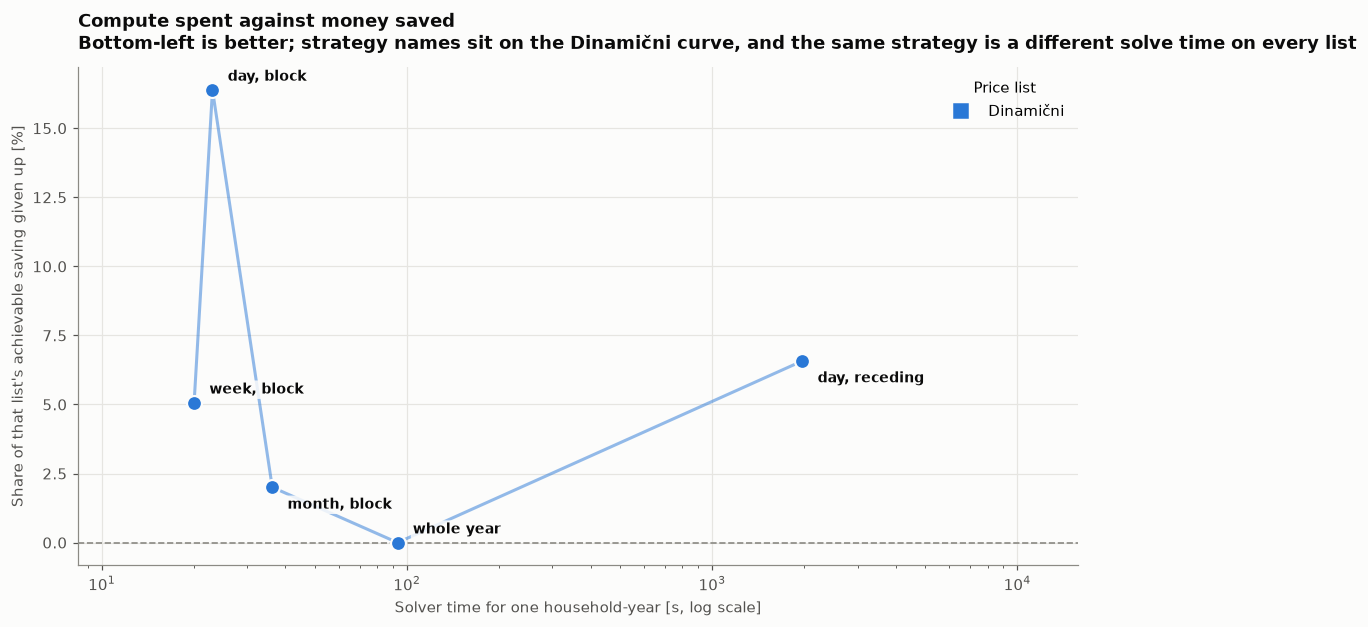

In [ ]:
### What the extra compute buys, on each price list
fig, ax = plt.subplots(figsize=(10.0, 5.8))

for tariff in TARIFFS_READY:
    xs = np.array([summary.loc[(tariff, s), "Runtime_s"] for s in STRAT_ORDER], dtype=float)
    ys = np.array([summary.loc[(tariff, s), "Gap_pct"] for s in STRAT_ORDER], dtype=float)
    order = np.argsort(xs)
    # One list's trade-off curve, cheapest solve to most expensive.
    ax.plot(xs[order], ys[order], lw=2.0, color=TARIFF_COLOR[tariff], alpha=0.5, zorder=2)
    for strat, xi, yi in zip(STRAT_ORDER, xs, ys):
        ax.scatter([xi], [yi], s=95, marker=MODE_MARKER[hc.STRATEGIES[strat][2]],
                   color=strat_color(tariff, strat), zorder=3, lw=1.4, edgecolor=SURFACE)

# Direct-label the strategies once, on the list whose curve is most spread out,
# rather than putting a label on all 20 points. Offsets alternate above/below so
# the labels survive the lists where three strategies collapse onto one corner.
anchor = max(TARIFFS_READY, key=lambda t: summary.loc[t, "Gap_pct"].max())
for k, strat in enumerate(STRAT_ORDER):
    ax.annotate(LABEL[strat],
                xy=(summary.loc[(anchor, strat), "Runtime_s"],
                    summary.loc[(anchor, strat), "Gap_pct"]),
                xytext=(10, 6 if k % 2 == 0 else -14), textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold", zorder=6,
                bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.85))

ax.set_xscale("log")
ax.set_xlim(float(summary["Runtime_s"].min()) / 2.4, float(summary["Runtime_s"].max()) * 8.0)
ax.axhline(0, color=MUTED, lw=1.1, ls="--")
ax.set_xlabel("Solver time for one household-year [s, log scale]")
ax.set_ylabel("Share of that list's achievable saving given up [%]")
ax.set_title("Compute spent against money saved\n"
             f"Bottom-left is better; strategy names sit on the {anchor} curve, and the same "
             "strategy is a different solve time on every list")
leg = tariff_legend(ax, loc="upper right", title="Price list")
if soc_mode_legend(ax, kind="marker", loc="center right", title="SOC mode"):
    ax.add_artist(leg)
plt.tight_layout()
plt.show()

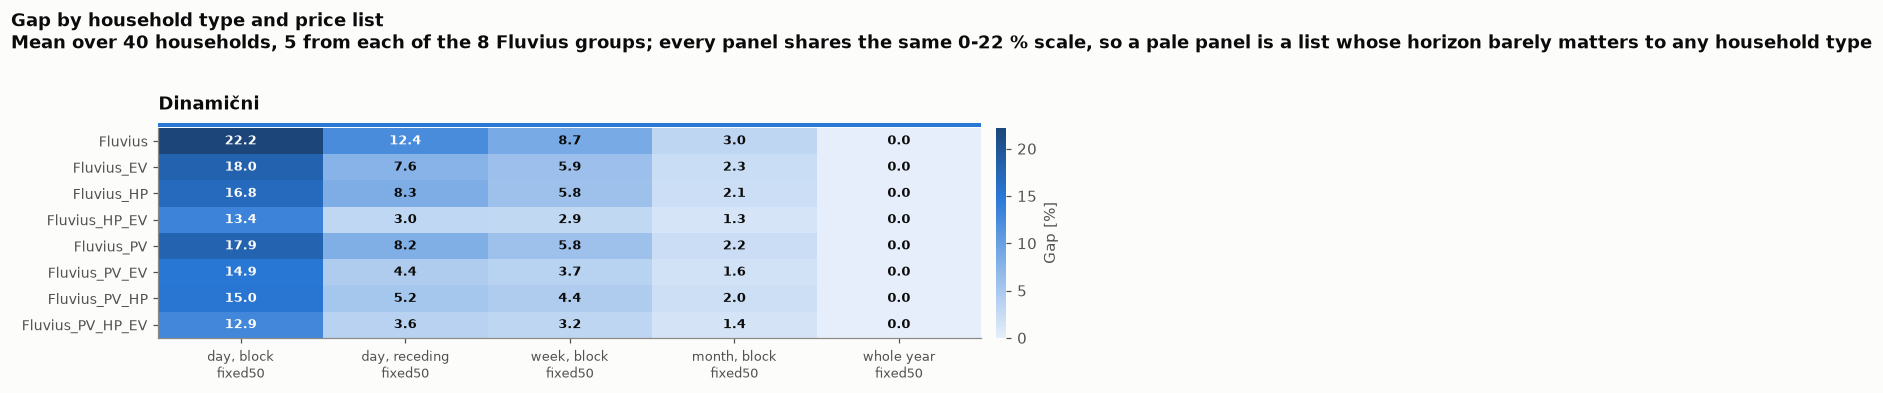

In [ ]:
### Does the household type change the answer? One panel per price list, one hue per panel
plot_cols = [s for s in STRAT_ORDER if s != "full_period_carry"]
vmax = float(np.nanmax(by_group[[(t, s) for t in TARIFFS_READY for s in plot_cols]].to_numpy()))

fig, axes = plt.subplots(len(TARIFFS_READY), 1,
                         figsize=(10.5, 3.6 * len(TARIFFS_READY)), squeeze=False)

for ax, tariff in zip(axes[:, 0], TARIFFS_READY):
    values = by_group[[(tariff, s) for s in plot_cols]].to_numpy()
    im = ax.imshow(values, cmap=TARIFF_RAMP[tariff], aspect="auto", vmin=0, vmax=vmax)

    ax.set_xticks(range(len(plot_cols)),
                  [f"{LABEL[s]}\n{hc.STRATEGIES[s][2]}" for s in plot_cols], fontsize=8.5)
    ax.set_yticks(range(by_group.shape[0]), by_group.index, fontsize=9)
    ax.grid(visible=False)
    for r in range(values.shape[0]):
        for c in range(values.shape[1]):
            v = values[r, c]
            ax.annotate(fmt_pct(v), xy=(c, r), ha="center", va="center", fontsize=8.5,
                        color=SURFACE if v > 0.55 * vmax else INK, fontweight="semibold")
    panel_title(ax, tariff)
    cbar = fig.colorbar(im, ax=ax, pad=0.015)
    cbar.set_label("Gap [%]", color=INK_2)
    cbar.outline.set_visible(False)

fig.suptitle("Gap by household type and price list\n"
             f"{SAMPLE}; every panel shares the same 0-{vmax:.0f} % scale, so a pale panel is "
             "a list whose horizon barely matters to any household type",
             x=0.005, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 5. Read-out

In [ ]:
lines = [
    f"{len(balanced)} household-units "
    f"({hc.HOUSEHOLDS_PER_GROUP} x {len(hc.DATASET_GROUPS)} Fluvius groups), "
    f"{hc.BATTERY_CAPACITY_KWH:.0f} kWh battery, full year, "
    f"{len(TARIFFS_READY)} price lists",
]

for tariff in TARIFFS_READY:
    tab = summary.loc[tariff]
    spec = hc.TARIFFS[tariff]
    fixed = [s for s in STRAT_ORDER if hc.STRATEGIES[s][2] == "fixed50"]
    non_optimal = [s for s in STRAT_ORDER if tab.loc[s, "Gap_pct"] > 1e-9]
    best = tab.loc[non_optimal, "Gap_pct"].idxmin() if non_optimal else STRAT_ORDER[0]
    grid_share = 100.0 * tab.loc[hc.REFERENCE_STRATEGY, "Grid_Charged_kWh"] / max(
        tab.loc[hc.REFERENCE_STRATEGY, "Charged_kWh"], 1e-9)

    lines += [
        "",
        "=" * 78,
        f"{tariff}  ({spec['paket_id']}, {spec['structure']}, "
        f"{'exports credited' if spec['buyback'] else 'no buyback'})",
        f"achievable saving {achievable[tariff]:.2f} EUR/a, so 1 pt of gap = "
        f"{achievable[tariff] / 100:.2f} EUR/a; the whole-year solve charges "
        f"{grid_share:.0f} % of its throughput off the grid",
        "",
        f"{'strategy':16s}{'SOC mode':10s}{'gap %':>8s}{'worst':>8s}{'gap EUR/a':>11s}"
        f"{'solves':>9s}{'time':>9s}",
    ]
    for strat in STRAT_ORDER:
        r = tab.loc[strat]
        lines.append(
            f"{LABEL[strat]:16s}{r['SOC_Mode']:10s}{r['Gap_pct']:7.2f}%{r['Worst_Gap_pct']:7.2f}%"
            f"{r['Gap_EUR']:11.2f}{r['Solves']:9,.0f}{r['Runtime_s']:8.0f}s"
        )

    pairs = [(a, f"{a}_carry") for a in fixed if f"{a}_carry" in tab.index]
    if pairs:
        lines += ["", "  Same horizon and execution, the two SOC modes side by side:"]
        for a, b in pairs:
            delta = tab.loc[b, "Gap_pct"] - tab.loc[a, "Gap_pct"]
            verdict = ("identical" if abs(delta) <= 0.005
                       else "carry is worse" if delta > 0 else "carry is better")
            lines.append(f"     {LABEL[a]:16s} {tab.loc[a, 'Gap_pct']:6.2f}% -> "
                         f"{tab.loc[b, 'Gap_pct']:6.2f}%  ({delta:+.2f} pts, {verdict})")

    steps = [("day_block", "week_block"), ("week_block", "month_block"),
             ("month_block", "full_period"),
             ("day_block_carry", "week_block_carry"),
             ("week_block_carry", "month_block_carry")]
    lines += ["", "  Longer horizon, same execution and SOC mode:"]
    for a, b in steps:
        if a in tab.index and b in tab.index:
            lines.append(f"     {LABEL[a]:16s} -> {LABEL[b]:16s} "
                         f"{tab.loc[a, 'Gap_pct'] - tab.loc[b, 'Gap_pct']:+6.2f} pts "
                         f"({hc.STRATEGIES[a][2]})")

    lines += ["", "  Re-planning every interval instead of committing to the block:"]
    for a, b in (("day_block", "day_receding"), ("day_block_carry", "day_receding_carry")):
        if a in tab.index and b in tab.index:
            lines.append(f"     {LABEL[a]:16s} {hc.STRATEGIES[a][2]:8s} "
                         f"{tab.loc[a, 'Gap_pct']:6.2f}% -> {tab.loc[b, 'Gap_pct']:6.2f}%  "
                         f"({tab.loc[b, 'Solves'] / tab.loc[a, 'Solves']:.0f}x the solves, "
                         f"{tab.loc[b, 'Runtime_s'] / max(tab.loc[a, 'Runtime_s'], 1e-9):.0f}x "
                         f"the time)")

    lines += ["", f"  Best non-clairvoyant strategy: {LABEL[best]} ({hc.STRATEGIES[best][2]}), "
                  f"{tab.loc[best, 'Gap_pct']:.2f} % short of the optimum "
                  f"({tab.loc[best, 'Gap_EUR']:.2f} EUR/a)"]

    spread = by_group[tariff].max(axis=0) - by_group[tariff].min(axis=0)
    lines += ["", "  Spread of the mean gap across the 8 household types [pts]:"]
    for strat in STRAT_ORDER:
        if strat in spread.index and spread[strat] > 1e-9:
            lines.append(f"     {LABEL[strat]:16s} {hc.STRATEGIES[strat][2]:8s} "
                         f"{spread[strat]:5.2f}")

lines += ["", "=" * 78, "Across the price lists", ""]
lines.append(f"{'price list':12s}{'structure':21s}{'achievable':>12s}"
             + "".join(f"{LABEL[s]:>16s}" for s in STRAT_ORDER))
for tariff in TARIFFS_READY:
    lines.append(
        f"{tariff:12s}{hc.TARIFFS[tariff]['structure']:21s}"
        f"{achievable[tariff]:10.0f}  "
        + "".join(f"{summary.loc[(tariff, s), 'Gap_pct']:15.2f}%" for s in STRAT_ORDER)
    )

day = {t: summary.loc[(t, 'day_block'), "Gap_pct"] for t in TARIFFS_READY
       if (t, "day_block") in summary.index}
if len(day) > 1:
    hardest, easiest = max(day, key=day.get), min(day, key=day.get)
    lines += [
        "",
        f"A day-ahead block controller gives up {day[hardest]:.2f} % on {hardest} and "
        f"{day[easiest]:.2f} % on {easiest}",
        f"-- {day[hardest] / max(day[easiest], 1e-9):.0f}x more of the achievable saving, "
        f"and {summary.loc[(hardest, 'day_block'), 'Gap_EUR']:.2f} against "
        f"{summary.loc[(easiest, 'day_block'), 'Gap_EUR']:.2f} EUR/a in money.",
        "The horizon question is a question about the price signal, not about the solver.",
    ]

print("\n".join(lines))

40 household-units (5 x 8 Fluvius groups), 30 kWh battery, full year, 1 price lists

Dinamični  (GENI_SAMO_DINAMICNI, dynamic (SIPX), exports credited)
achievable saving 740.99 EUR/a, so 1 pt of gap = 7.41 EUR/a; the whole-year solve charges 90 % of its throughput off the grid

strategy        SOC mode     gap %   worst  gap EUR/a   solves     time
day, block      fixed50     16.39%  24.58%     119.23      366      23s
day, receding   fixed50      6.58%  14.42%      46.78   35,135    1978s
week, block     fixed50      5.06%   9.85%      36.21       53      20s
month, block    fixed50      2.00%   3.32%      14.46       12      36s
whole year      fixed50     -0.00%   0.00%       0.00        1      93s

  Longer horizon, same execution and SOC mode:
     day, block       -> week, block      +11.32 pts (fixed50)
     week, block      -> month, block      +3.06 pts (fixed50)
     month, block     -> whole year        +2.00 pts (fixed50)

  Re-planning every interval instead of committing 

### What this does and does not show

* **Every strategy still has perfect foresight inside its horizon.** A day-ahead controller here
  knows tomorrow's SIPX prices, PV and load exactly; real forecast error lands on top and hurts
  the long horizons most. These gaps are therefore a *lower* bound on what a short horizon costs
  in practice — and the bound is loosest on **Dinamični**, whose price signal is the one nobody
  can actually forecast. On **Redni 1T** and **Redni 2T** the supplier price is known a year
  ahead by contract, so almost the whole remaining gap is real rather than an artefact of
  perfect foresight; what is left to forecast there is the household's own load and PV.
* **A percentage on one list is not a percentage on another.** `Gap_pct` divides by that list's
  own achievable saving, which is what makes it comparable *across households*. Across *lists*
  the denominators differ by a large factor, so a small percentage on a list with a big
  achievable saving can still be more euros than a large percentage on a list with a small one.
  The `Achievable [EUR/a]` column and `Gap [EUR/a]` are there to settle that; the first panel in
  section 4 plots the denominators on their own.
* **Watch the grid-charged share on the block lists.** `Aktivni` has a fixed 4-block price list
  whose spread is known to the solver a year in advance, so a battery can buy in the cheapest
  block and sell in the most expensive one *every single day* regardless of PV. The
  `Grid charged [%]` column says how much of the throughput that is. Where it is high, the
  achievable saving is an arbitrage against the price list rather than a benefit of storing own
  production, and the horizon result for that list should be read as "how much of a *repeating
  daily* pattern does a horizon capture" — which is why a day is nearly enough there.
* **Why `carry` is not automatically better.** Stored energy has no value in a MILP objective
  that stops at the horizon end, so a *block* strategy under `carry` runs the battery flat at
  every boundary and hands the next period an empty battery. `fixed50` at least hands over a
  usable 15 kWh. Fixing this properly needs a terminal *value* on stored energy (a price on the
  residual SOC), not a terminal constraint — that is the natural next experiment. Both families
  are commented out in `Horizon_Comparison.STRATEGIES` at the moment; uncomment them and every
  panel picks them up as a second shade and hatch of each list's hue.
* **`full_period_carry` is identical to `full_period` by construction** — one period, pinned at
  both ends. It is kept in the table as a consistency check on the SOC bookkeeping.
* **One price list at a time, across all eight groups.** Each of the four lists is applied to the
  non-PV groups too, so the horizon effect is not confounded by who holds which contract. Three
  of the four are samooskrba lists, which formally require a self-supply device; for a household
  with no PV what they measure is the import side alone. `Redni 2T` (`GENI_REDNI`) is the plain
  list and is quotable to anyone — it is also what a PV household is on when its connection is
  approved with a 0 kW export limit.
* **All four lists are dispatched under `si_samooskrba`.** The alternative for the plain list
  (`si_dobava`) credits exports at the full retail rate including network charges and VAT, which
  makes grid arbitrage unbounded. `tip_odkupa=NI` on `GENI_REDNI` is what actually zeroes its
  export credit, and it does so under either dispatcher.
* **`full_period` carries a 0.1 % MIP gap** (`hc.FULL_PERIOD_GAP_REL`), the others are solved to
  proven optimality inside their horizon. On these bills that is a few tenths of a euro — below
  the gaps in the table, but not zero, and it is why a `full_period` gap prints as -0.00 % on
  some units.